# Neighborhood and Host Performance Analysis

This notebook answers: which neighborhoods and host profiles truly outperform in Paris?

Neighborhood performance
       neighborhood  listing_count  avg_nightly_price  avg_review_score  occupancy_proxy_pct
             Élysée           1901             539.67              4.72                36.53
     Palais-Bourbon           1586             527.59              4.74                42.84
              Passy           3272             481.65              4.76                38.92
             Louvre           1375             442.00              4.75                42.57
             Bourse           2159             402.91              4.69                42.58
         Luxembourg           1716             392.17              4.73                44.96
              Opéra           2364             365.37              4.76                44.23
     Hôtel-de-Ville           1736             359.24              4.76                47.26
             Temple           2498             355.91              4.72                45.76
Batignolles-Monceau           3097           

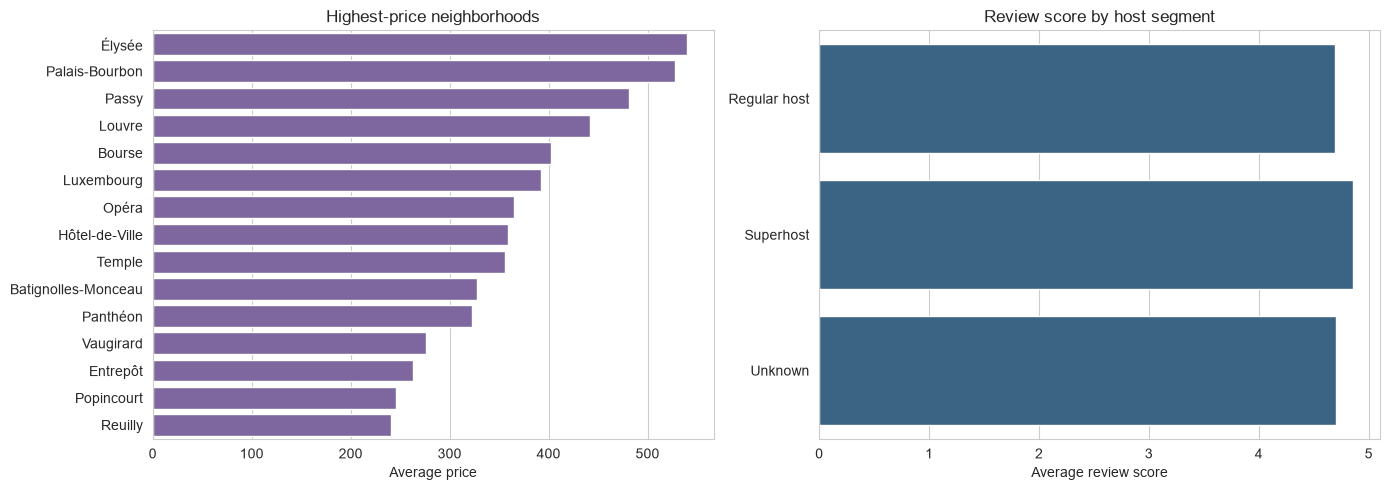

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

sns.set_style("whitegrid")
load_dotenv(Path(r"C:\Users\LENOVO\Desktop\csv-to-postgres") / ".env")
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PGUSER', 'postgres')}:{os.getenv('PGPASSWORD', '')}@"
    f"{os.getenv('PGHOST', 'localhost')}:{os.getenv('PGPORT', '5432')}/{os.getenv('PGDATABASE', 'csv_project')}"
)

neighborhoods = pd.read_sql(
    """
    SELECT
        neighbourhood_cleansed AS neighborhood,
        COUNT(*) AS listing_count,
        ROUND(AVG(price), 2) AS avg_nightly_price,
        ROUND(AVG(review_scores_rating), 2) AS avg_review_score,
        ROUND(AVG((365 - availability_365) * 100.0 / 365), 2) AS occupancy_proxy_pct
    FROM listings_clean
    WHERE neighbourhood_cleansed IS NOT NULL AND price IS NOT NULL AND price > 0
    GROUP BY neighbourhood_cleansed
    HAVING COUNT(*) >= 25
    ORDER BY avg_nightly_price DESC
    LIMIT 15
    """,
    engine,
)

hosts = pd.read_sql(
    """
    SELECT
        CASE
            WHEN host_is_superhost IS TRUE THEN 'Superhost'
            WHEN host_is_superhost IS FALSE THEN 'Regular host'
            ELSE 'Unknown'
        END AS host_segment,
        COUNT(*) AS listing_count,
        ROUND(AVG(price), 2) AS avg_nightly_price,
        ROUND(AVG(review_scores_rating), 2) AS avg_review_score,
        ROUND(AVG((365 - availability_365) * 100.0 / 365), 2) AS occupancy_proxy_pct
    FROM listings_clean
    WHERE price IS NOT NULL AND price > 0
    GROUP BY host_segment
    ORDER BY listing_count DESC
    """,
    engine,
)

print("Neighborhood performance")
print(neighborhoods.to_string(index=False))
print("\nHost performance")
print(hosts.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=neighborhoods, x="avg_nightly_price", y="neighborhood", ax=axes[0], color="#7b5ea7")
axes[0].set_title("Highest-price neighborhoods")
axes[0].set_xlabel("Average price")
axes[0].set_ylabel("")
sns.barplot(data=hosts, x="avg_review_score", y="host_segment", ax=axes[1], color="#2f6690")
axes[1].set_title("Review score by host segment")
axes[1].set_xlabel("Average review score")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()